In [45]:
# Import modules
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio 
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import scipy.signal as ss
from statsmodels.tsa.seasonal import STL
from sklearn.impute import KNNImputer
from scipy.interpolate import interp1d
import math
import glob
import os
import re
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Polygon  # 若数据是格点，需生成网格的多边形几何
from rasterio.mask import mask
from cartopy.feature import ShapelyFeature
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
#1.

#read the csv file
eqs = pd.read_csv("usgs_earthquakes.csv")
eqs

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.708100,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.130900,0.00,1.33,ml,4.0,171.43,0.342000,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.252800,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.957500,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.692500,10.59,1.34,ml,6.0,285.00,0.043210,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120103,2014-12-01 00:10:16.000,60.963900,-146.762900,14.80,3.80,ml,NaN,NaN,NaN,0.6900,ak,ak11453391,2015-03-24T18:25:07.628Z,"29km SW of Valdez, Alaska",earthquake
120104,2014-12-01 00:09:39.000,58.869100,-154.415900,108.40,2.40,ml,NaN,NaN,NaN,0.6700,ak,ak11453395,2014-12-10T01:04:25.209Z,"102km SSE of Old Iliamna, Alaska",earthquake
120105,2014-12-01 00:09:25.350,38.843498,-122.825836,2.37,0.43,md,8.0,107.00,0.008991,0.0300,nc,nc72358451,2014-12-01T01:15:02.814Z,"9km WNW of Cobb, California",earthquake
120106,2014-12-01 00:05:54.000,65.152100,-148.992000,9.50,0.40,ml,NaN,NaN,NaN,0.6900,ak,ak11453390,2014-12-10T01:03:01.225Z,"57km NW of Ester, Alaska",earthquake


In [3]:
# Sort in descending order
eqs1 = eqs.sort_values("mag", ascending=False).head(50)

In [4]:
#第一次作出的图少了几个点，倒回来到这里把所有大于等于6.5级的都选上
eqs1 = eqs.loc[eqs['mag'] >= 6.5].sort_values("mag", ascending=False)
eqs1.info()
#一共有54个点

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 37371 to 103919
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       54 non-null     object 
 1   latitude   54 non-null     float64
 2   longitude  54 non-null     float64
 3   depth      54 non-null     float64
 4   mag        54 non-null     float64
 5   magType    54 non-null     object 
 6   nst        0 non-null      float64
 7   gap        53 non-null     float64
 8   dmin       53 non-null     float64
 9   rms        54 non-null     float64
 10  net        54 non-null     object 
 11  id         54 non-null     object 
 12  updated    54 non-null     object 
 13  place      54 non-null     object 
 14  type       54 non-null     object 
dtypes: float64(8), object(7)
memory usage: 6.8+ KB


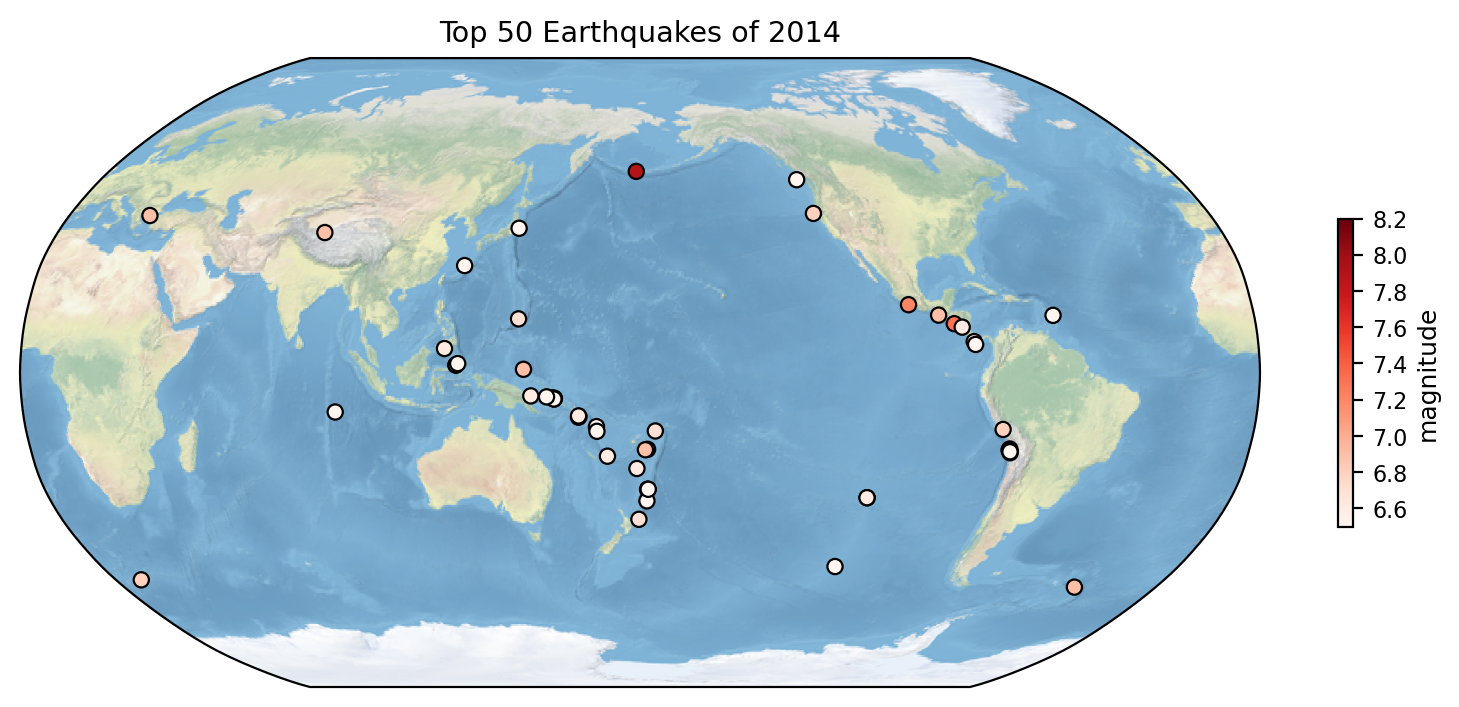

In [5]:
#对于colorbar和scatterplot的写法不熟悉，询问了ai
#source:豆包

# Create and define the size of a figure object 
plt.figure(figsize=(10,10), dpi=200)

# Create an axes with an basic PlateCarree projection style
proj = ccrs.Robinson(central_longitude=180)
ax = plt.axes(projection=proj)

# 4. 添加底图（栅格/矢量都可以，这里用NaturalEarth的地形底图）
ax.stock_img()

lons = eqs1['longitude']
lats = eqs1['latitude']
mags = eqs1['mag']
sc = ax.scatter(lons, lats, c=mags, cmap='Reds',transform=ccrs.PlateCarree(),
           edgecolor='black', linewidths=0.8, s=30)

cbar = plt.colorbar(sc, ax=ax, shrink=0.2)
cbar.set_label("magnitude", rotation=90, labelpad=3, fontsize=9) 
cbar.set_ticks([6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0, 8.2])  # 匹配例图刻度
cbar.ax.tick_params(labelsize=8)
               
ax.set_title("Top 50 Earthquakes of 2014", fontsize=10.35)
ax.spines['geo'].set_visible(True)  # 显示例图的椭圆形边框

plt.show()

In [6]:
#2.
#use the same dataset used in Assignment 03

# Load the netCDF4 file
prep = xr.open_dataset("ps31/GPCP_gauge_precip_timeseries_202101-2023071.nc4", engine="netcdf4")
prep

<xarray.Dataset> Size: 64MB
Dimensions:           (time: 31, lat: 360, lon: 720)
Coordinates:
  * lon               (lon) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat               (lat) float32 1kB 89.75 89.25 88.75 ... -89.25 -89.75
  * time              (time) datetime64[ns] 248B 2021-01-01 ... 2023-07-01
Data variables:
    gauge_precip      (time, lat, lon) float32 32MB ...
    satellite_precip  (time, lat, lon) float32 32MB ...
Attributes: (12/66)
    ShortName:                      GPCPMON
    LongName:                       GPCP Precipitation Level 3 Monthly 0.5-De...
    VersionID:                      3.2
    GranuleID:                      GPCPMON_L3_202101_V3.2.nc4
    Format:                         NetCDF-4
    RangeBeginningDate:             2021-01-01
    ...                             ...
    Distribution_Size:              Approximately 7 MB per file
    Distribution_Format:            NetCDF-4
    IdentifierProductDOIAuthority:  http://dx.doi.org/
    Fees:                           None
    ProcessingLevel:                Level 3
    Institution:                    Mesoscale Atmospheric Processes Laborator...

In [7]:
prep.gauge_precip

<xarray.DataArray 'gauge_precip' (time: 31, lat: 360, lon: 720)> Size: 32MB
[8035200 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) datetime64[ns] 248B 2021-01-01 2021-02-01 ... 2023-07-01
Attributes:
    units:         mm/day
    long_name:     wind-loss adjusted gauge precipitation
    valid_range:   [  0. 100.]
    cell_methods:  time: mean

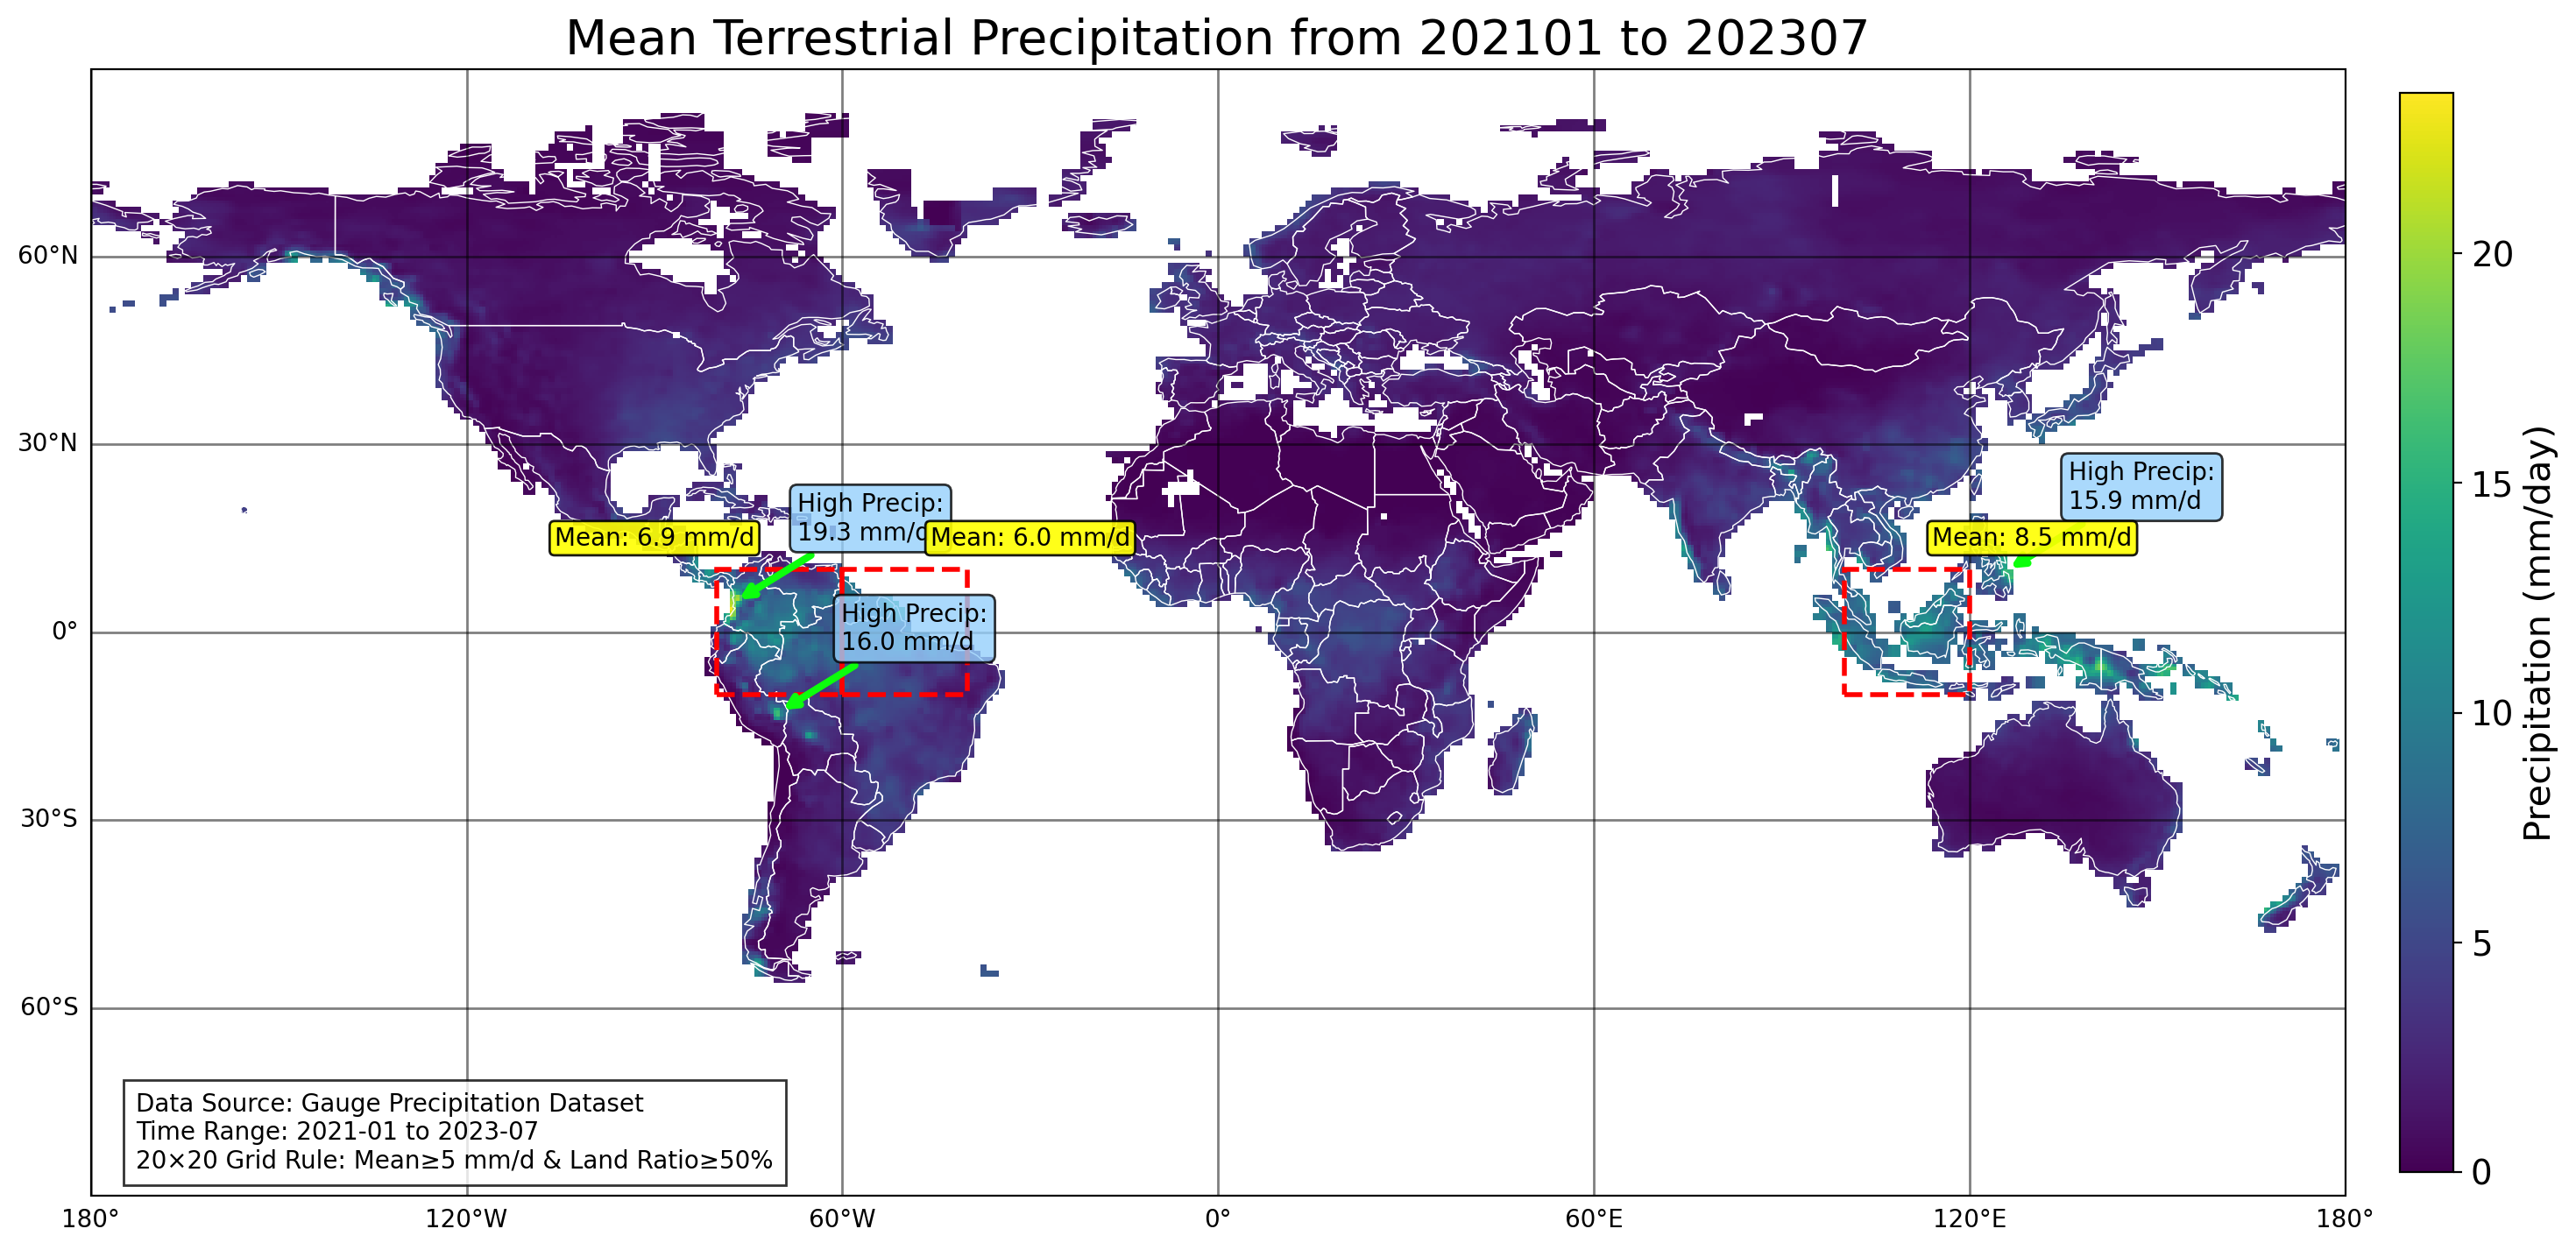

In [8]:
#做一个提取时间内的全世界降水平均分布图

#对注释、提取网格、注释不互相遮挡、色条等不是很清楚 #source: AI

# Create and define the size of a figure object 
plt.figure(figsize=(20,20), dpi=200)

# Create an axes with Orthographic projection style
#proj = ccrs.Orthographic(central_lon, central_lat) 
proj = ccrs.PlateCarree() 
ax   = plt.axes(projection=proj)

prep_mean = prep.gauge_precip.mean(dim='time')
# Plot the surface temperature
sc = prep_mean.plot(ax=ax, transform=ccrs.PlateCarree(),
         cbar_kwargs={'shrink': 0.4, 'label': 'Precipitation (mm/day)', 'pad': 0.02})

# Add border lines over countries 
ax.add_feature(cfeature.NaturalEarthFeature(category='cultural',
                                           name='admin_0_countries',
                                            scale ='110m',
                                           facecolor='none',
                                           edgecolor='white',
                                           linewidth=0.5))

# Add lat/lon gridlines, draw gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='black', alpha=0.5, draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
gl.ylocator = mticker.FixedLocator([-90, -60, -30, 0, 30, 60, 90])
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}


grid_size = 20  
mean_threshold = 5  #20x20网格总平均值≥5
land_ratio_threshold = 0.5  # 20x20网格中陆地/有数据网格占比≥50%（海洋≤50%）
max_annotations = 3  


lons = prep_mean.lon.values
lats = prep_mean.lat.values
prep_vals = prep_mean.values


lon_starts = np.arange(-180, 180, grid_size)
lat_starts = np.arange(-90, 90, grid_size)

annotated_count = 0
annot_positions = [
    (0, 2),   # 第1个：网格上方2°
    (25, 7),  # 第2个：右25°+上7°
    (-25, 7)  # 第3个：左25°+上7°
]

#提取网格
annotated_count = 0  
for lon_start in lon_starts:
    if annotated_count >= max_annotations:
        break
    lon_end = lon_start + grid_size
    for lat_start in lat_starts:
        lat_end = lat_start + grid_size
        
        # 提取当前网格的经纬度索引
        lon_mask = (lons >= lon_start) & (lons <= lon_end)
        lat_mask = (lats >= lat_start) & (lats <= lat_end)
        if not np.any(lon_mask) or not np.any(lat_mask):
            continue
        
        # 提取当前网格的所有数据
        grid_data = prep_vals[lat_mask][:, lon_mask]
        total_grid_num = grid_data.size  # 网格总数（陆地+海洋）
        land_grid_num = np.count_nonzero(~np.isnan(grid_data))  # 陆地/有数据网格数
        
        # 跳过：网格总数太少 或 陆地占比不足60%
        if total_grid_num < 5 or (land_grid_num / total_grid_num) < land_ratio_threshold:
            continue
        
        # 计算陆地/有数据网格的均值
        land_data = grid_data[~np.isnan(grid_data)]
        grid_mean = np.mean(land_data)

        if grid_mean >= mean_threshold:
            
    # 绘制矩形框
            rect = mpatches.Rectangle(
                (lon_start, lat_start), grid_size, grid_size,
                linewidth=2, edgecolor='red', linestyle='--', facecolor='none',
                transform=ccrs.PlateCarree(), zorder=5)
            ax.add_patch(rect)
    
            center_lon = (lon_start + lon_end) / 2
            center_lat = lat_end + 2
            land_ratio = land_grid_num / total_grid_num

            if lon_start == -80:  # 美洲区域的网格
                final_lon = center_lon - 20  # 左移20°
                final_lat = center_lat + 5   # 上移5°
            elif lon_start == 100:  # 亚洲区域的网格
                final_lon = center_lon + 20  # 右移20°
                final_lat = center_lat + 5   # 上移5°
            else:  # 其他区域
                final_lon = center_lon + 20
                final_lat = center_lat + 5  

    # 绘制清晰的标注（分行显示，避免重叠）
            ax.text(
                final_lon, final_lat,
                f'Mean: {grid_mean:.1f} mm/d',
                ha='center', va='top', fontsize=10,  # 缩小字体+调整对齐
                bbox=dict(boxstyle='round,pad=0.2', fc='yellow', ec='black', alpha=0.9),
                transform=ccrs.PlateCarree(), zorder=100)   
            annotated_count += 1
            if annotated_count >= max_annotations:
                break


# 自动标注高降水区域
high_precip_threshold = 15  # 定义高降水阈值（可调整）

lons = prep_mean.lon.values
lats = prep_mean.lat.values
prep_vals = prep_mean.values

# 找出高降水区域的坐标
high_precip_coords = []
for i, lon in enumerate(lons):
    for j, lat in enumerate(lats):
        val = prep_vals[j, i]
        if not np.isnan(val) and val >= high_precip_threshold:
            high_precip_coords.append((lon, lat, val))

# 去重（避免重复标注）
unique_coords = list(set([(round(lon, 1), round(lat, 1)) for lon, lat, val in high_precip_coords]))
# 自动标注前5个高降水区域
for idx, (lon, lat) in enumerate(unique_coords[:3]):
    ax.annotate(f'High Precip:\n{prep_mean.sel(lon=lon, lat=lat, method="nearest").values:.1f} mm/d',
        xy=(lon, lat),
        xytext=(lon+10, lat+10),  # 文本偏移
        fontsize=10,
        arrowprops=dict(arrowstyle='->', color='xkcd:neon green', lw=3),
        bbox=dict(boxstyle='round,pad=0.3', fc='xkcd:light blue', alpha=0.8),
        zorder=10)  # 置顶显示

ax.text(
    0.02, 0.02,
    'Data Source: Gauge Precipitation Dataset\nTime Range: 2021-01 to 2023-07\n20×20 Grid Rule: Mean≥5 mm/d & Land Ratio≥50%',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(boxstyle='square,pad=0.5', fc='white', alpha=0.8),
    verticalalignment='bottom')

ax.set_title("Mean Terrestrial Precipitation from 202101 to 202307", fontsize=20)
sc.colorbar.ax.tick_params(labelsize=14)
sc.colorbar.set_label(label='Precipitation (mm/day)', fontsize=15)
plt.show()

In [9]:
#2.2 

#做一个中国地区的2021和2022年总降水对比图

# 1. 读取中国国界shp（确保坐标系是WGS84，EPSG:4326）
china_shp = gpd.read_file("国界/国家矢量.shp").to_crs(epsg=4326)
print("✅ 国界shp读取成功，数据量：", len(china_shp))

# 2. 读取你的降水数据（以xarray为例，若为CSV则用pd.read_csv）
precip_data = xr.open_dataset("ps31/GPCP_gauge_precip_timeseries_202101-2023071.nc4")
print(precip_data)

# 提取经纬度和降水值，转为DataFrame（示例：假设数据维度是lat/lon/time）
df_precip = precip_data.sel(time=slice("2021-01", "2023-07")).mean(dim="time").to_dataframe().reset_index()
df_precip

✅ 国界shp读取成功，数据量： 1
<xarray.Dataset> Size: 64MB
Dimensions:           (time: 31, lat: 360, lon: 720)
Coordinates:
  * lon               (lon) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat               (lat) float32 1kB 89.75 89.25 88.75 ... -89.25 -89.75
  * time              (time) datetime64[ns] 248B 2021-01-01 ... 2023-07-01
Data variables:
    gauge_precip      (time, lat, lon) float32 32MB ...
    satellite_precip  (time, lat, lon) float32 32MB ...
Attributes: (12/66)
    ShortName:                      GPCPMON
    LongName:                       GPCP Precipitation Level 3 Monthly 0.5-De...
    VersionID:                      3.2
    GranuleID:                      GPCPMON_L3_202101_V3.2.nc4
    Format:                         NetCDF-4
    RangeBeginningDate:             2021-01-01
    ...                             ...
    Distribution_Size:              Approximately 7 MB per file
    Distribution_Format:            NetCDF-4
    IdentifierProductDOIAuthority:  http:/

,lat,lon,gauge_precip,satellite_precip
0,89.75,-179.75,NaN,0.710422
1,89.75,-179.25,NaN,0.710422
2,89.75,-178.75,NaN,0.710422
3,89.75,-178.25,NaN,0.710422
4,89.75,-177.75,NaN,0.710422
...,...,...,...,...
259195,-89.75,177.75,NaN,0.253563
259196,-89.75,178.25,NaN,0.253563
259197,-89.75,178.75,NaN,0.253563
259198,-89.75,179.25,NaN,0.253563


In [10]:
# 格点分辨率是0.5°×0.5°
res_lon, res_lat = 0.5, 0.5

def grid_to_polygon(lon, lat, res_lon, res_lat):
    """将单个格点的经纬度转为多边形"""
    return Polygon([
        (lon - res_lon/2, lat - res_lat/2),
        (lon + res_lon/2, lat - res_lat/2),
        (lon + res_lon/2, lat + res_lat/2),
        (lon - res_lon/2, lat + res_lat/2)
    ])

# 给每个格点生成多边形几何
df_precip["geometry"] = df_precip.apply(
    lambda row: grid_to_polygon(row["lon"], row["lat"], res_lon, res_lat),
    axis=1
)

# 转为GeoDataFrame
gdf_precip = gpd.GeoDataFrame(df_precip, crs="EPSG:4326")
gdf_precip

,lat,lon,gauge_precip,satellite_precip,geometry
0,89.75,-179.75,NaN,0.710422,"POLYGON ((-180 89.5, -179.5 89.5, -179.5 90, -..."
1,89.75,-179.25,NaN,0.710422,"POLYGON ((-179.5 89.5, -179 89.5, -179 90, -17..."
2,89.75,-178.75,NaN,0.710422,"POLYGON ((-179 89.5, -178.5 89.5, -178.5 90, -..."
3,89.75,-178.25,NaN,0.710422,"POLYGON ((-178.5 89.5, -178 89.5, -178 90, -17..."
4,89.75,-177.75,NaN,0.710422,"POLYGON ((-178 89.5, -177.5 89.5, -177.5 90, -..."
...,...,...,...,...,...
259195,-89.75,177.75,NaN,0.253563,"POLYGON ((177.5 -90, 178 -90, 178 -89.5, 177.5..."
259196,-89.75,178.25,NaN,0.253563,"POLYGON ((178 -90, 178.5 -90, 178.5 -89.5, 178..."
259197,-89.75,178.75,NaN,0.253563,"POLYGON ((178.5 -90, 179 -90, 179 -89.5, 178.5..."
259198,-89.75,179.25,NaN,0.253563,"POLYGON ((179 -90, 179.5 -90, 179.5 -89.5, 179..."


In [11]:
# 方法：保留与中国国界相交的格点（用intersects覆盖边界格点）
gdf_china_precip = gpd.overlay(gdf_precip, china_shp, how="intersection")
# （若数据是点而非格点，用gpd.sjoin(gdf_precip, china_shp, predicate="within")）

# 打印列名，找到正确的降水变量名
print("✅ gdf_china_precip的所有列名：")
print(gdf_china_precip.columns.tolist())

# 也可以打印前几行数据，直观查看
print("\n✅ gdf_china_precip前5行数据：")
print(gdf_china_precip.head())

✅ gdf_china_precip的所有列名：
['lat', 'lon', 'gauge_precip', 'satellite_precip', '地名', 'ENG_NAME', 'year', 'geometry']

✅ gdf_china_precip前5行数据：
     lat     lon  gauge_precip  satellite_precip       地名  \
0  53.75  122.25      1.777828          1.474686  中华人民共和国   
1  53.75  123.25      1.792227          1.388287  中华人民共和国   
2  53.75  123.75      1.812718          1.413555  中华人民共和国   
3  53.25  120.25      1.582846          1.578681  中华人民共和国   
4  53.25  120.75      1.618462          1.546426  中华人民共和国   

                         ENG_NAME  year  \
0  the People's Republic of China  2021   
1  the People's Republic of China  2021   
2  the People's Republic of China  2021   
3  the People's Republic of China  2021   
4  the People's Republic of China  2021   

                                            geometry  
0  POLYGON ((122.33076 53.5, 122.33128 53.50006, ...  
1  MULTIPOLYGON (((123.03017 53.5, 123.03025 53.5...  
2  MULTIPOLYGON (((123.50098 53.5, 123.50098 53.5...  
3  POLYGON ((1

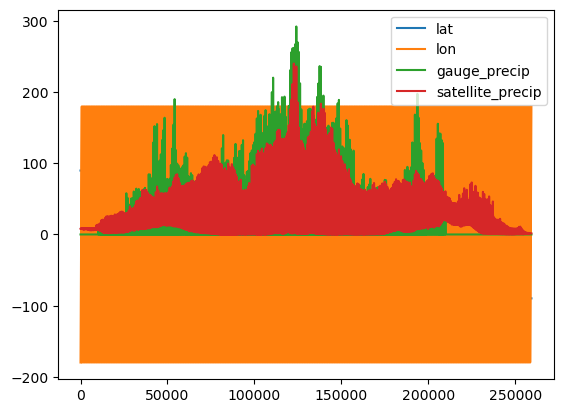

,lat,lon,gauge_precip,satellite_precip
0,89.75,-179.75,0.0,9.861413
1,89.75,-179.25,0.0,9.861413
2,89.75,-178.75,0.0,9.861413
3,89.75,-178.25,0.0,9.861413
4,89.75,-177.75,0.0,9.861413
...,...,...,...,...
259195,-89.75,177.75,0.0,4.351597
259196,-89.75,178.25,0.0,4.351597
259197,-89.75,178.75,0.0,4.351597
259198,-89.75,179.25,0.0,4.351597


In [12]:
# 绘制中国国界2021和2022年年总降水量分布图

# 提取经纬度和降水值，转为DataFrame
df_precip_21 = precip_data.sel(time=slice("2021-01", "2021-12")).sum(dim="time").to_dataframe().reset_index()
df_precip_22 = precip_data.sel(time=slice("2022-01", "2022-12")).sum(dim="time").to_dataframe().reset_index()

df_precip_21.plot()
plt.show()
df_precip_22
#卫星观测数据普遍比整合后数据低

In [13]:
df_precip_21["geometry"] = df_precip.apply(
    lambda row: grid_to_polygon(row["lon"], row["lat"], res_lon, res_lat),
    axis=1
)
df_precip_22["geometry"] = df_precip.apply(
    lambda row: grid_to_polygon(row["lon"], row["lat"], res_lon, res_lat),
    axis=1
)

gdf_precip_21 = gpd.GeoDataFrame(df_precip_21, crs="EPSG:4326")
gdf_precip_22 = gpd.GeoDataFrame(df_precip_22, crs="EPSG:4326")
gdf_precip_21
gdf_precip_22


,lat,lon,gauge_precip,satellite_precip,geometry
0,89.75,-179.75,0.0,9.861413,"POLYGON ((-180 89.5, -179.5 89.5, -179.5 90, -..."
1,89.75,-179.25,0.0,9.861413,"POLYGON ((-179.5 89.5, -179 89.5, -179 90, -17..."
2,89.75,-178.75,0.0,9.861413,"POLYGON ((-179 89.5, -178.5 89.5, -178.5 90, -..."
3,89.75,-178.25,0.0,9.861413,"POLYGON ((-178.5 89.5, -178 89.5, -178 90, -17..."
4,89.75,-177.75,0.0,9.861413,"POLYGON ((-178 89.5, -177.5 89.5, -177.5 90, -..."
...,...,...,...,...,...
259195,-89.75,177.75,0.0,4.351597,"POLYGON ((177.5 -90, 178 -90, 178 -89.5, 177.5..."
259196,-89.75,178.25,0.0,4.351597,"POLYGON ((178 -90, 178.5 -90, 178.5 -89.5, 178..."
259197,-89.75,178.75,0.0,4.351597,"POLYGON ((178.5 -90, 179 -90, 179 -89.5, 178.5..."
259198,-89.75,179.25,0.0,4.351597,"POLYGON ((179 -90, 179.5 -90, 179.5 -89.5, 179..."


In [26]:
# 用intersects覆盖边界格点）
#这一步会运行很久，大概4分钟左右
gdf_china_precip_21 = gpd.overlay(gdf_precip_21, china_shp, how="intersection")
gdf_china_precip_22 = gpd.overlay(gdf_precip_22, china_shp, how="intersection")
gdf_china_precip_21
gdf_china_precip_22

,lat,lon,gauge_precip,satellite_precip,地名,ENG_NAME,year,geometry
0,53.75,122.25,20.747383,16.647934,中华人民共和国,the People's Republic of China,2021,"POLYGON ((122.33076 53.5, 122.33128 53.50006, ..."
1,53.75,123.25,21.302145,15.188258,中华人民共和国,the People's Republic of China,2021,"MULTIPOLYGON (((123.03017 53.5, 123.03025 53.5..."
2,53.75,123.75,21.724424,15.323149,中华人民共和国,the People's Republic of China,2021,"MULTIPOLYGON (((123.50098 53.5, 123.50098 53.5..."
3,53.25,120.25,19.742435,18.167965,中华人民共和国,the People's Republic of China,2021,"POLYGON ((120.5 53, 120.43417 53, 120.43423 53..."
4,53.25,120.75,19.781654,17.269646,中华人民共和国,the People's Republic of China,2021,"POLYGON ((121 53, 120.5 53, 120.5 53.03651, 12..."
...,...,...,...,...,...,...,...,...
4301,5.75,112.75,0.000000,104.599617,中华人民共和国,the People's Republic of China,2021,"MULTIPOLYGON (((112.6052 5.5, 112.60239 5.5187..."
4302,5.25,112.25,0.000000,107.145576,中华人民共和国,the People's Republic of China,2021,"POLYGON ((112.5 5.00462, 112.49591 5.0016, 112..."
4303,5.25,112.75,0.000000,110.162041,中华人民共和国,the People's Republic of China,2021,"MULTIPOLYGON (((112.65034 5, 112.64417 5.00255..."
4304,4.75,112.75,0.000000,117.895050,中华人民共和国,the People's Republic of China,2021,"MULTIPOLYGON (((112.9432 5, 112.93945 4.99292,..."


In [16]:
# 打印时间维度的间隔（单位：小时）
time_delta = precip_data["time"].diff(dim="time").mean().values.astype('timedelta64[h]').astype(int)
print(f"数据的时间分辨率：{time_delta} 小时")
#728小时，即一个月

数据的时间分辨率：728 小时


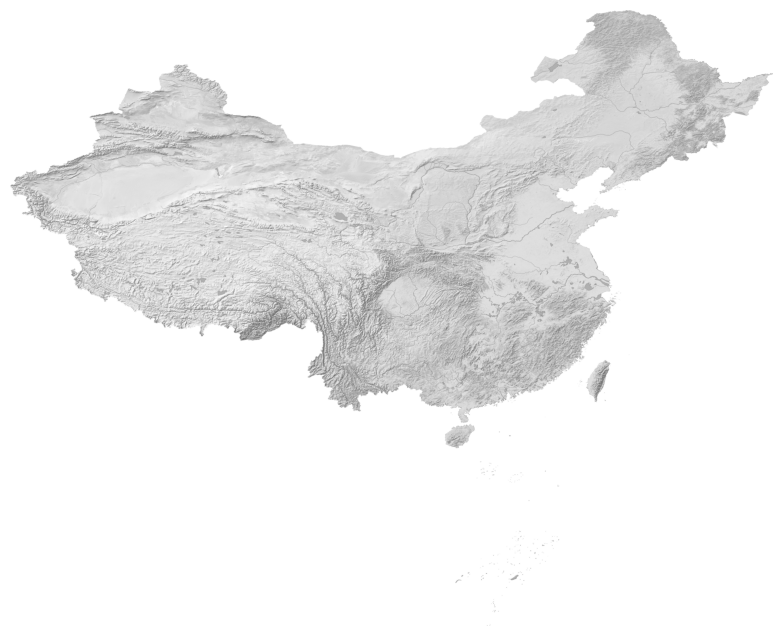

底图extent： [73.5000000000507, 135.10000000006303, 3.833333333316112, 53.566666666659394]


In [40]:
# 1. 读取国界shp
china_geom = [feature["geometry"] for feature in china_shp.__geo_interface__["features"]]

# 地形图TIFF来源：Natural Earth I with Shaded Relief, Water, and Drainages
# https://www.naturalearthdata.com/downloads/10m-raster-data/10m-natural-earth-1/
# With Shaded Relief, Water, and Drainages Coloring based on land cover. Download large size (309.3 MB) version 3.2.0

# 2. 裁剪TIFF（nodata用255
tiff_path = "NE1_HR_LC_SR_W_DR.tif"
with rasterio.open(tiff_path) as src:
    clipped_tiff, clipped_transform = mask(
        src, 
        china_geom, 
        crop=True,
        nodata=255  # uint8支持的最大值（白色）
    )
    clipped_extent = [
        clipped_transform.c,
        clipped_transform.c + clipped_transform.a * clipped_tiff.shape[2],
        clipped_transform.f + clipped_transform.e * clipped_tiff.shape[1],
        clipped_transform.f
    ]

# 3. 转为灰度图
terrain_gray = np.mean(clipped_tiff[:3], axis=0).astype(np.uint8)  # 转为uint8

# 4. 正确显示底图
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(
    terrain_gray,
    cmap="gray",
    origin="upper",
    vmin=0, vmax=255  # 匹配uint8的取值范围
)
ax.axis("off")
plt.show()

print("底图extent：", clipped_extent)  # 验证范围

2021年降水最大值： 4134.1572265625
2022年降水最大值： 4923.01416015625


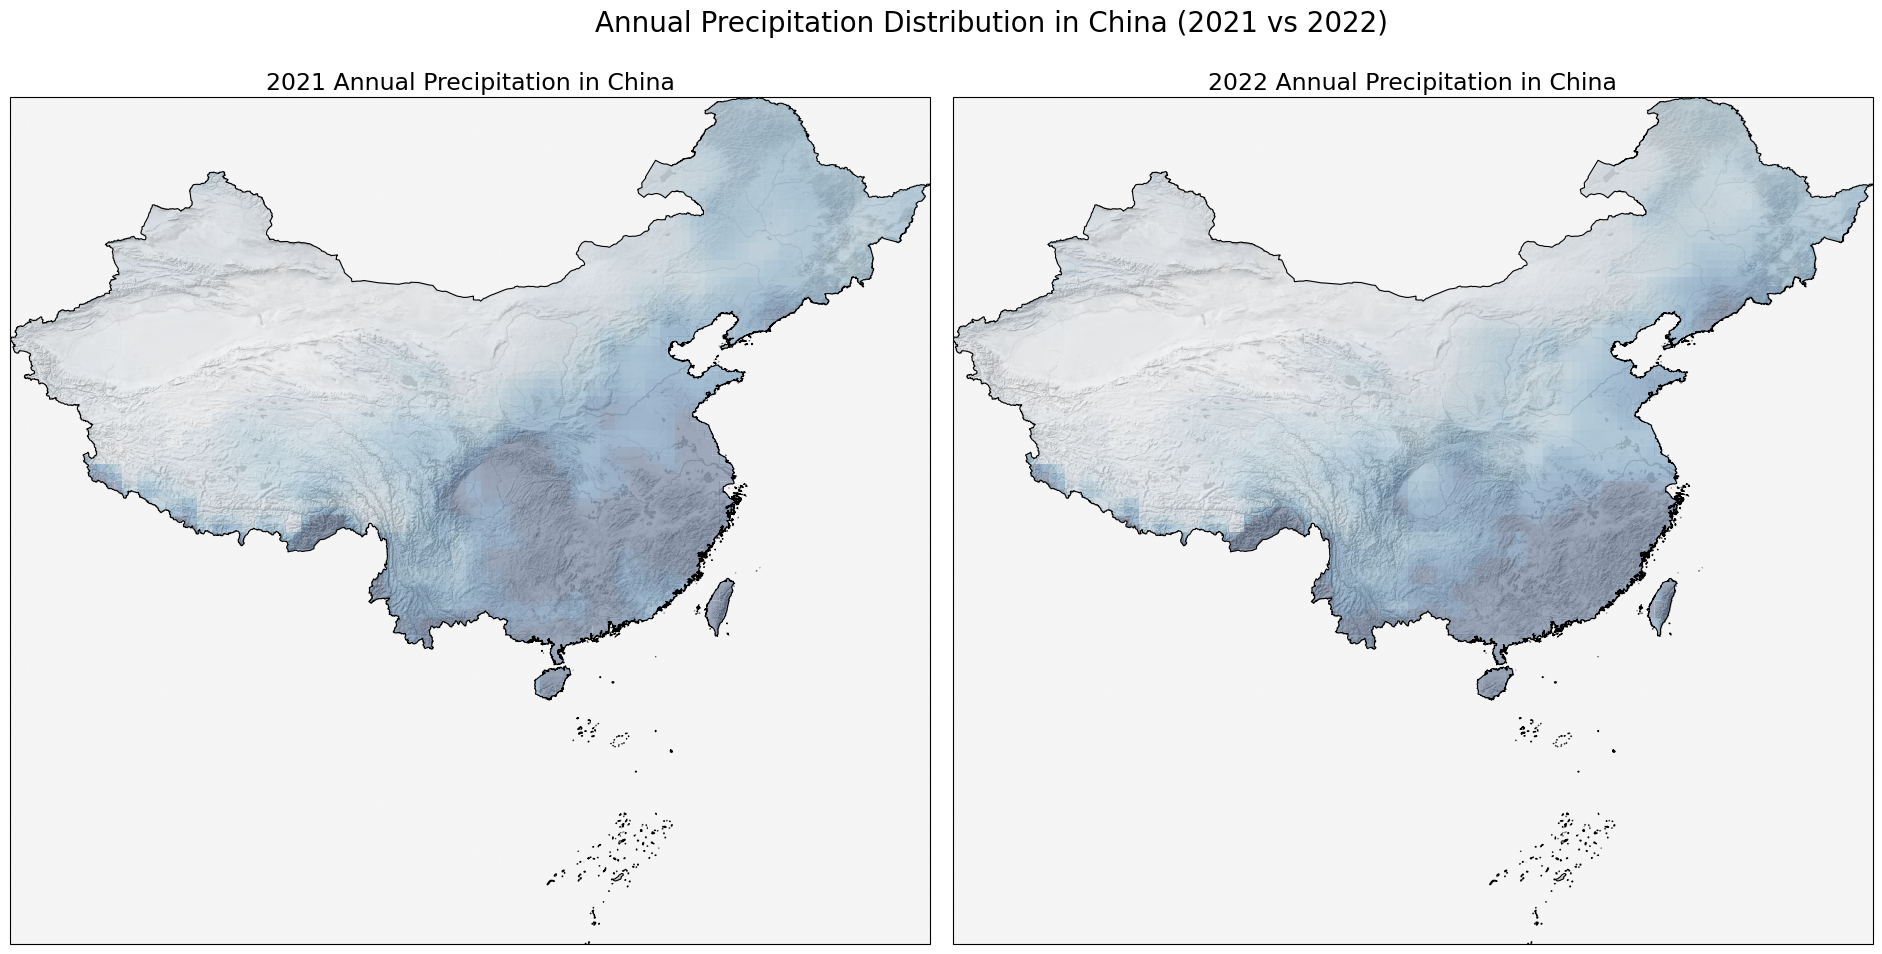

In [27]:
#绘图
# 底图在降水层下方
# 1. 自定义颜色（浅灰系）

# 增加深色占比，缩小浅色系范围，放大地形明暗差异
terrain_cmap = LinearSegmentedColormap.from_list(
    "high_contrast_terrain",
     ["#606060", "#a0a0a0", "#d0d0d0", "#f5f5f5"]  # 深灰→中灰→浅灰→白（对比度更高）加深深色端，拉大明暗差
)

precip_cmap = "Blues"
vmin_precip = 0
vmax_precip = 2000
precip_ticks = [0, 200, 400, 600, 800, 1000, 1500, 2000]

gdf_china_precip_21_y = gdf_china_precip_21.copy(deep=True)
gdf_china_precip_22_y = gdf_china_precip_22.copy(deep=True)
gdf_china_precip_21_y["gauge_precip"] = gdf_china_precip_21["gauge_precip"] * 30
gdf_china_precip_22_y["gauge_precip"] = gdf_china_precip_22["gauge_precip"] * 30
# 注意要加copy(deep=True)

print("2021年降水最大值：", gdf_china_precip_21_y["gauge_precip"].max())
print("2022年降水最大值：", gdf_china_precip_22_y["gauge_precip"].max())


# 2. 绘图（TIFF底图+降水层+国界）
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for idx, ax in enumerate([ax1, ax2]):
    # 步骤1：绘制底图（最下层）
    ax.imshow(
        terrain_gray,
        extent=clipped_extent,
        cmap=terrain_cmap,
        alpha=1,
        origin="upper",
        transform=ccrs.PlateCarree()
    )    
    
    # 步骤2：绘制降水层（中间层，alpha=0.3）
    if idx == 0:
        gdf_china_precip_21_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.3, 
            vmin=0,
            vmax=1500,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2021 Annual Precipitation in China", fontsize=17)
    else:
        # 2022年降水（共享色条）
        gdf_china_precip_22_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.3, 
            vmin=0,
            vmax=1500,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2022 Annual Precipitation in China", fontsize=17)

    
    # 步骤3：绘制国界（最顶层，降低linewidth）
    china_feature = ShapelyFeature(
        china_shp.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='black',
        linewidth=0.8  # 细线，避免覆盖
    )
    ax.add_feature(china_feature)
    
    # 步骤4：限定中国范围
    ax.set_extent(clipped_extent, crs=ccrs.PlateCarree())

fig.suptitle("Annual Precipitation Distribution in China (2021 vs 2022)", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.show()

2021年降水最大值： 4134.1572265625
2022年降水最大值： 4923.01416015625


C:\Users\YiChen\AppData\Local\Temp\ipykernel_11112\1480884264.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


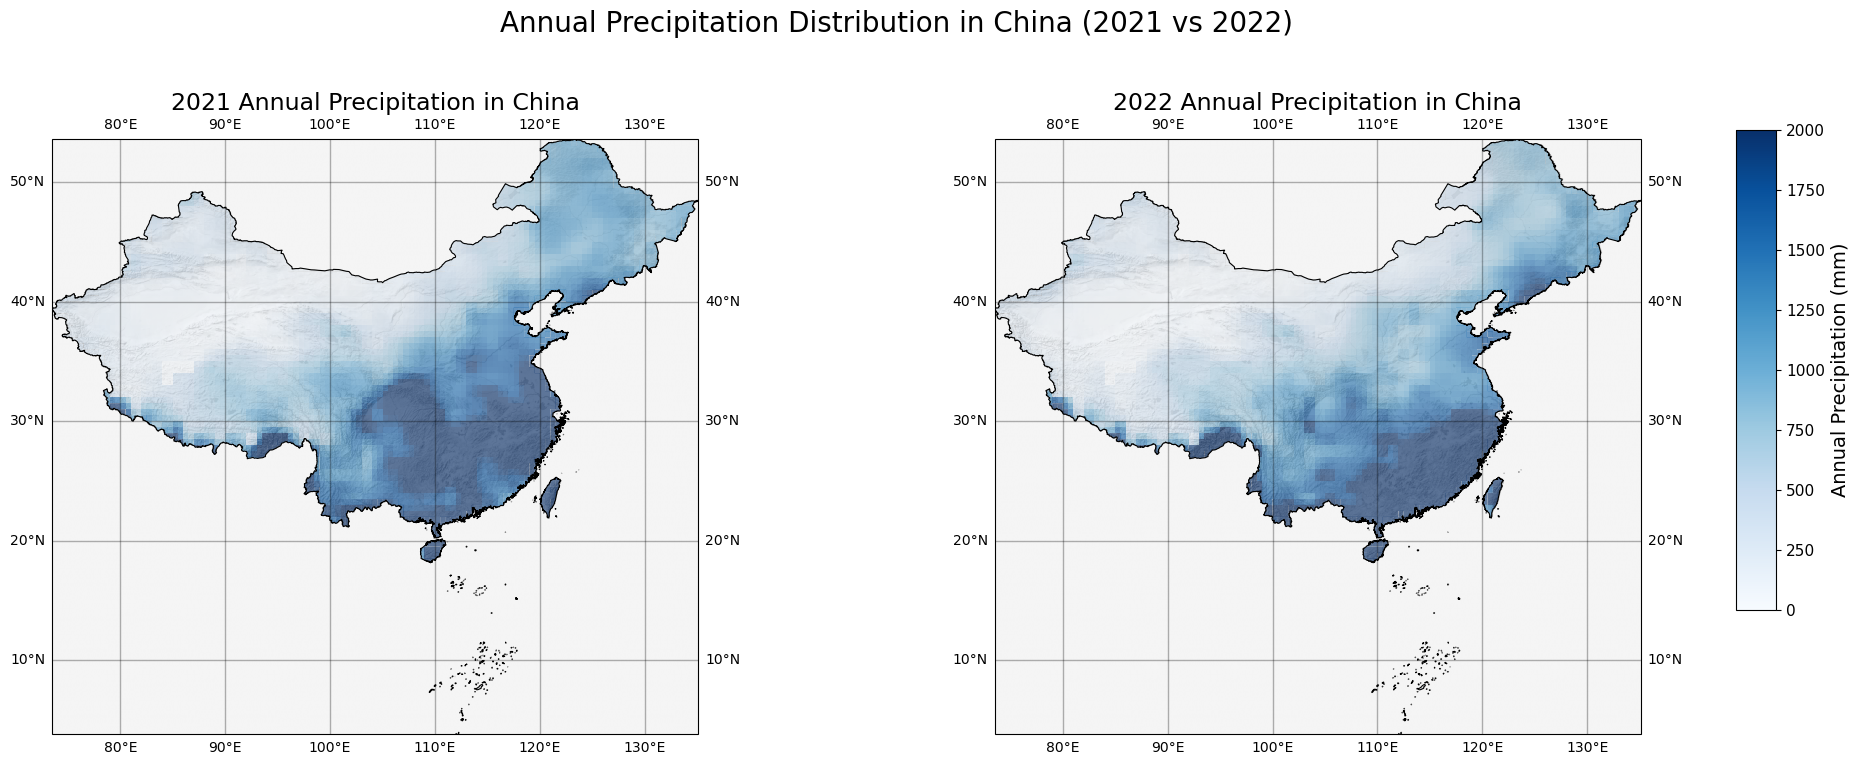

In [31]:
#绘图
# 底图在降水层下方
# 1. 自定义颜色（浅灰系）

# 增加深色占比，缩小浅色系范围，放大地形明暗差异
terrain_cmap = LinearSegmentedColormap.from_list(
    "high_contrast_terrain",
     ["#606060", "#a0a0a0", "#d0d0d0", "#f5f5f5"]  # 深灰→中灰→浅灰→白（对比度更高）加深深色端，拉大明暗差
)

precip_cmap = "Blues"
vmin_precip = 0
vmax_precip = 2000
precip_ticks = [0, 200, 400, 600, 800, 1000, 1500, 2000]

gdf_china_precip_21_y = gdf_china_precip_21.copy(deep=True)
gdf_china_precip_22_y = gdf_china_precip_22.copy(deep=True)
gdf_china_precip_21_y["gauge_precip"] = gdf_china_precip_21["gauge_precip"]*30
gdf_china_precip_22_y["gauge_precip"] = gdf_china_precip_22["gauge_precip"]*30
# 注意要加copy(deep=True)

print("2021年降水最大值：", gdf_china_precip_21_y["gauge_precip"].max())
print("2022年降水最大值：", gdf_china_precip_22_y["gauge_precip"].max())


# 2. 绘图（TIFF底图+降水层+国界）
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 8),
    sharex=True, sharey=True,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for idx, ax in enumerate([ax1, ax2]):
    # 步骤1：绘制底图（最下层）
    ax.imshow(
        terrain_gray,
        extent=clipped_extent,
        cmap=terrain_cmap,
        alpha=1,
        origin="upper",
        transform=ccrs.PlateCarree()
    )    
    
    # 步骤2：绘制降水层（中间层，alpha=0.3）
    if idx == 0:
        gdf_china_precip_21_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.4, 
            vmin=0,
            vmax=1500,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2021 Annual Precipitation in China", fontsize=17)
    else:
        # 2022年降水（共享色条）
        gdf_china_precip_22_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.4, 
            vmin=0,
            vmax=1500,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2022 Annual Precipitation in China", fontsize=17)

    
    # 步骤3：绘制国界（最顶层，降低linewidth）
    china_feature = ShapelyFeature(
        china_shp.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='black',
        linewidth=0.8  # 细线，避免覆盖
    )
    ax.add_feature(china_feature)

    ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='black', alpha=0.3, draw_labels=True)
    #ax.set_xticks(range(80, 140, 10), crs=ccrs.PlateCarree())  
    #ax.set_yticks(range(10, 60, 10), crs=ccrs.PlateCarree())   
    #ax.set_xlabel("Longitude (°E)", fontsize=14)
    #ax.set_ylabel("Latitude (°N)", fontsize=14)
    #ax.tick_params(axis="both", labelsize=12) 
    ax.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
    ax.ylocator = mticker.FixedLocator([-90, -60, -30, 0, 30, 60, 90])


    # 步骤4：限定中国范围
    ax.set_extent(clipped_extent, crs=ccrs.PlateCarree())

    # 5. 单独创建色条轴（不占用子图空间）
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [左, 下, 宽, 高]，独立于子图
norm = mpl.colors.Normalize(vmin=vmin_precip, vmax=vmax_precip)
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=precip_cmap),
    cax=cbar_ax,  # 指定色条轴
    label="Annual Precipitation (mm)"
)
# 1. 调整色条标签（label）的字体大小
cbar.set_label("Annual Precipitation (mm)", fontsize=14)  
# 2. 调整色条刻度文字的字体大小
cbar.ax.tick_params(labelsize=11) 

fig.suptitle("Annual Precipitation Distribution in China (2021 vs 2022)", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.show()

2021年降水最大值： 4134.1572265625
2022年降水最大值： 4923.01416015625


C:\Users\YiChen\AppData\Local\Temp\ipykernel_11112\2126423698.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


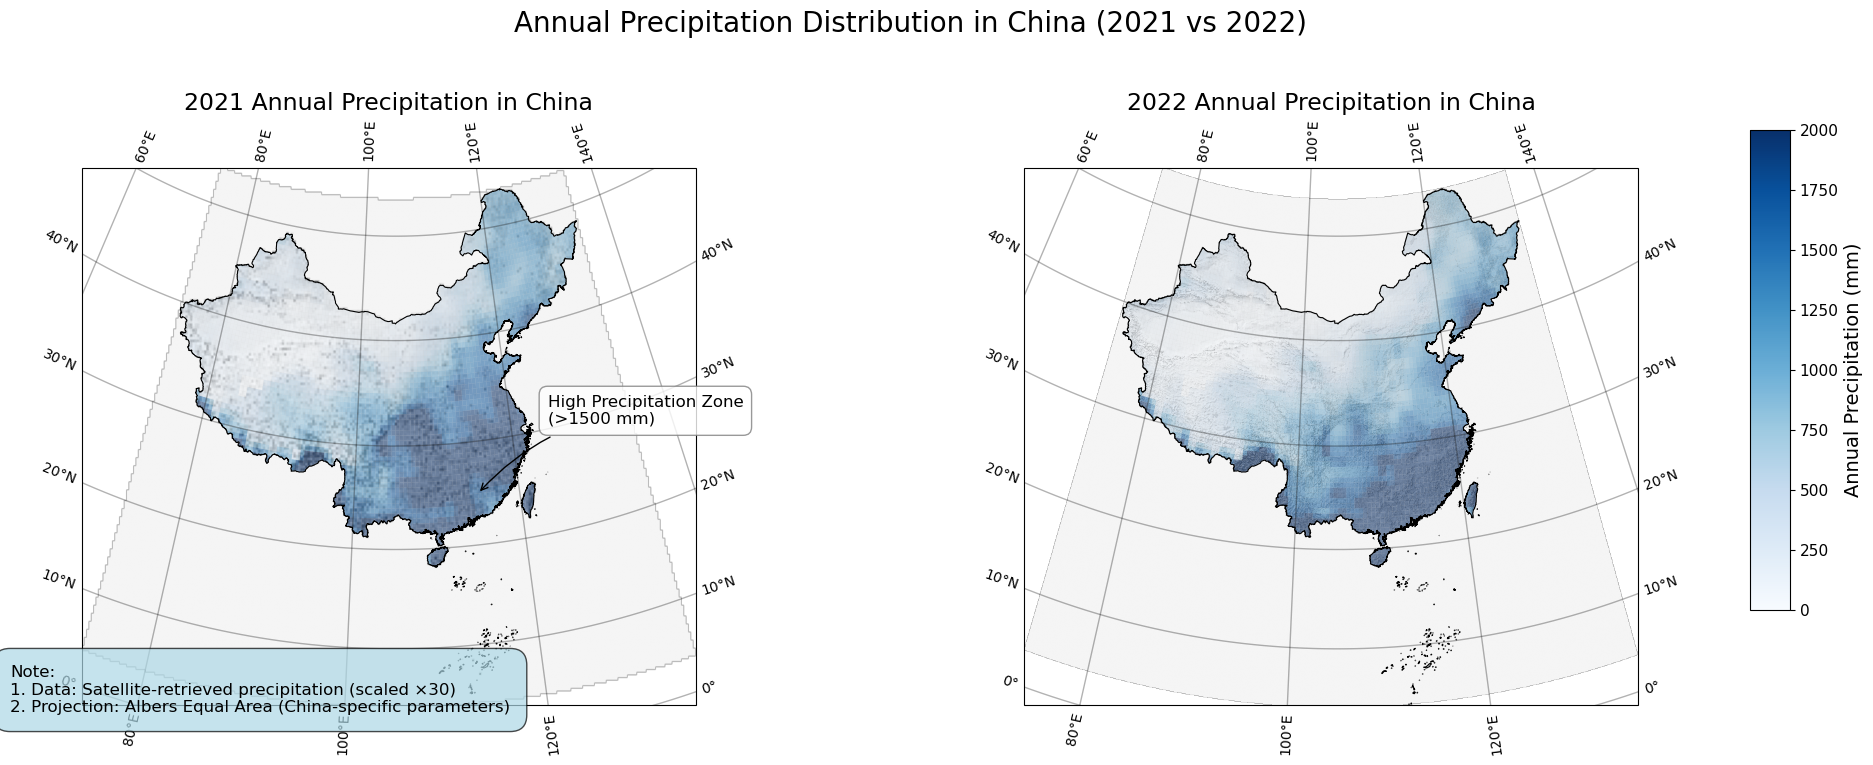

In [41]:
#绘图
# 底图在降水层下方
# 1. 自定义颜色（浅灰系）

aea_proj = ccrs.AlbersEqualArea( #阿尔伯特投影
    central_longitude=105,  # 中央经线
    standard_parallels=(25, 47),  # 标准纬线
    central_latitude=0
)

# 增加深色占比，缩小浅色系范围，放大地形明暗差异
terrain_cmap = LinearSegmentedColormap.from_list(
    "high_contrast_terrain",
     ["#606060", "#a0a0a0", "#d0d0d0", "#f5f5f5"]  # 深灰→中灰→浅灰→白（对比度更高）加深深色端，拉大明暗差
)

precip_cmap = "Blues" #色系
vmin_precip = 0
vmax_precip = 2000
precip_ticks = [0, 200, 400, 600, 800, 1000, 1500, 2000]

gdf_china_precip_21_y = gdf_china_precip_21.copy(deep=True)
gdf_china_precip_22_y = gdf_china_precip_22.copy(deep=True)
gdf_china_precip_21_y["gauge_precip"] = gdf_china_precip_21["gauge_precip"]*30 #粗略地乘以一个30，估算年总降水量
gdf_china_precip_22_y["gauge_precip"] = gdf_china_precip_22["gauge_precip"]*30
# 注意要加copy(deep=True)

print("2021年降水最大值：", gdf_china_precip_21_y["gauge_precip"].max())
print("2022年降水最大值：", gdf_china_precip_22_y["gauge_precip"].max())


# 2. 绘图（TIFF底图+降水层+国界）
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 8),
    sharex=True, sharey=True,
    subplot_kw={"projection": aea_proj} #投影参数转给子图
)

for idx, ax in enumerate([ax1, ax2]):
    # 步骤1：绘制底图（最下层）
    ax.imshow(
        terrain_gray,
        extent=[73.5000000000507, 135.10000000006303, 3.833333333316112, 53.566666666659394],
        cmap=terrain_cmap,
        alpha=1,
        origin="upper",
        transform=ccrs.PlateCarree() # 原始数据是WGS84
    )    
    
    # 步骤2：绘制降水层（中间层，alpha=0.3）
    if idx == 0:
        gdf_china_precip_21_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.5,
            vmin=0,
            vmax=1500,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2021 Annual Precipitation in China", fontsize=17)
    else:
        # 2022年降水（共享色条）
        gdf_china_precip_22_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.5, 
            vmin=0,
            vmax=1500,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2022 Annual Precipitation in China", fontsize=17)

    
    # 步骤3：绘制国界（最顶层，降低linewidth）
    china_feature = ShapelyFeature(
        china_shp.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='black',
        linewidth=0.8  # 细线，避免覆盖
    )
    ax.add_feature(china_feature)

    ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='black', alpha=0.3, draw_labels=True)
    #ax.set_xticks(range(80, 140, 10), crs=ccrs.PlateCarree())  
    #ax.set_yticks(range(10, 60, 10), crs=ccrs.PlateCarree())   
    #ax.set_xlabel("Longitude (°E)", fontsize=14)
    #ax.set_ylabel("Latitude (°N)", fontsize=14)
    #ax.tick_params(axis="both", labelsize=12) 
    ax.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
    ax.ylocator = mticker.FixedLocator([-90, -60, -30, 0, 30, 60, 90])


    # 步骤4：限定中国范围
    ax.set_extent([73.5000000000507, 135.10000000006303, 3.833333333316112, 53.566666666659394], crs=ccrs.PlateCarree())

# ===================== 4. 标注（Annotations）与文本框（Text Box） =====================
# 4.1 标注2021年华南高值区（示例坐标，可根据实际调整）
ax1.annotate(
    "High Precipitation Zone\n(>1500 mm)",  # 标注文字
    xy=(115, 25),  # 实际经纬度
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax1),
    xytext=(50, 50),  # 标注框位置
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color="black"),
    fontsize=12
)

# 4.2 添加说明文本框
textstr = "Note:\n1. Data: Satellite-retrieved precipitation (scaled ×30)\n2. Projection: Albers Equal Area (China-specific parameters)"
props = dict(boxstyle="round,pad=1", facecolor="lightblue", alpha=0.7)
fig.text(
    0.05, 0.1, textstr,
    transform=fig.transFigure,
    fontsize=12,
    verticalalignment="center",
    bbox=props
)

    # 5. 单独创建色条轴（不占用子图空间）
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [左, 下, 宽, 高]，独立于子图
norm = mpl.colors.Normalize(vmin=vmin_precip, vmax=vmax_precip)
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=precip_cmap),
    cax=cbar_ax,  # 指定色条轴
    label="Annual Precipitation (mm)"
)

cbar.set_label("Annual Precipitation (mm)", fontsize=14)  
cbar.ax.tick_params(labelsize=11) 


fig.suptitle("Annual Precipitation Distribution in China (2021 vs 2022)", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.show()

2021年降水最大值： 4134.1572265625
2022年降水最大值： 4923.01416015625


C:\Users\YiChen\AppData\Local\Temp\ipykernel_11112\416250750.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


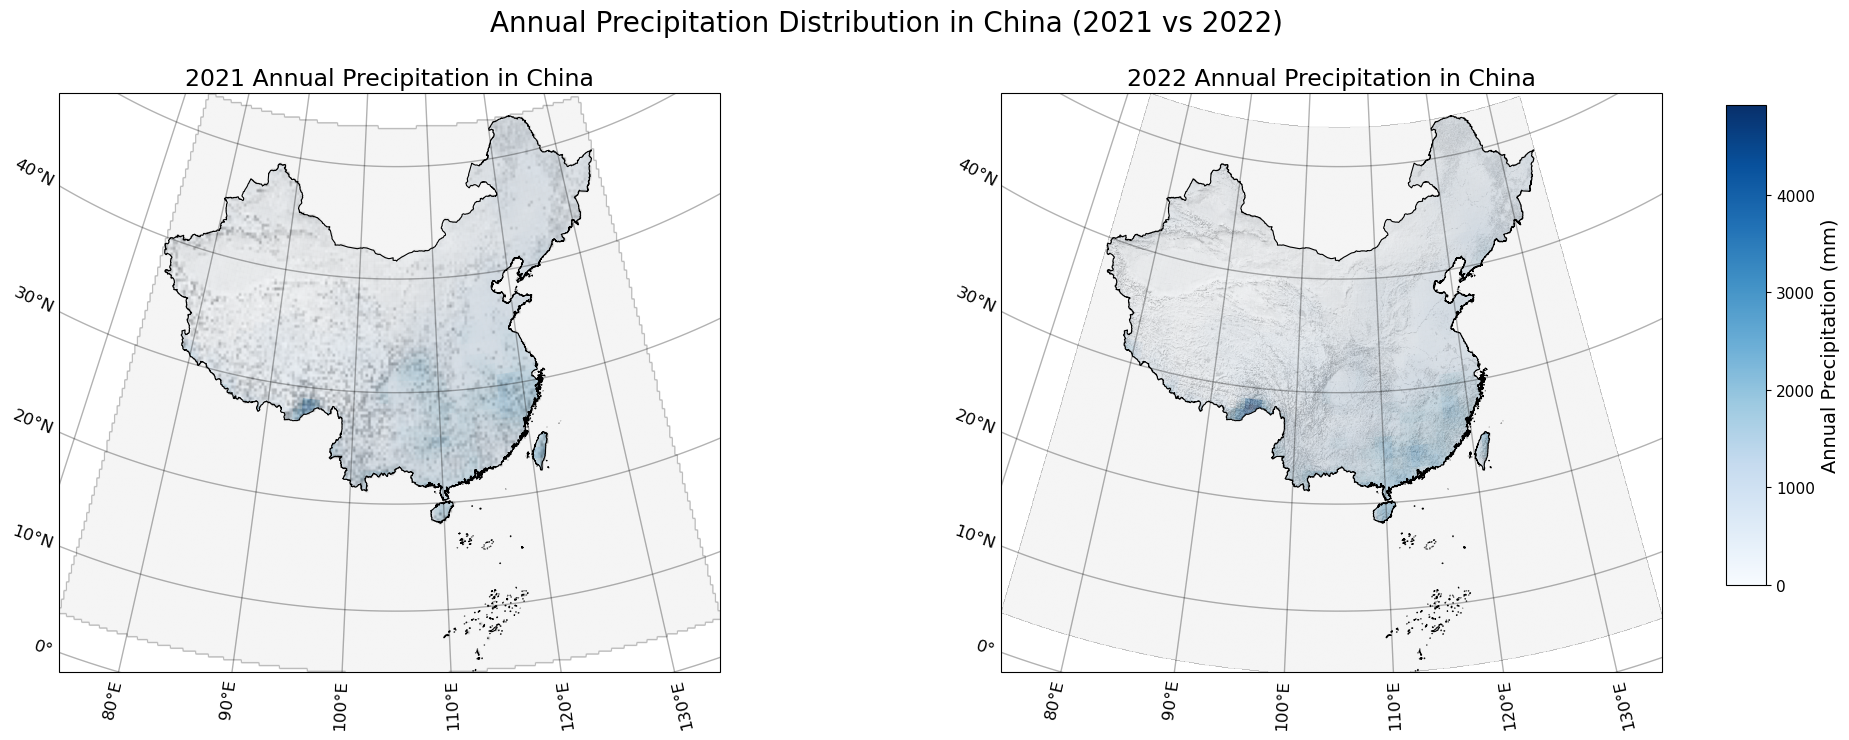

In [42]:

#改变一下vmax，使用数据最大值作为vmax

# ===================== 1. 投影与基础配置 =====================
# 定义中国阿尔伯特等面积投影
aea_proj = ccrs.AlbersEqualArea(
    central_longitude=105,
    standard_parallels=(25, 47),
    central_latitude=0
)
# 颜色配置
terrain_cmap = LinearSegmentedColormap.from_list(
    "high_contrast_terrain",
    ["#606060", "#a0a0a0", "#d0d0d0", "#f5f5f5"]
)
precip_cmap = "Blues"
# 读取国界
china_shp = gpd.read_file("国界/国家矢量.shp").to_crs(epsg=4326)

# ===================== 2. 数据处理 =====================
gdf_china_precip_21_y = gdf_china_precip_21.copy(deep=True)
gdf_china_precip_22_y = gdf_china_precip_22.copy(deep=True)
gdf_china_precip_21_y["gauge_precip"] = gdf_china_precip_21["gauge_precip"] * 30
gdf_china_precip_22_y["gauge_precip"] = gdf_china_precip_22["gauge_precip"] * 30
vmin_precip = 0
vmax_precip = max(gdf_china_precip_21_y["gauge_precip"].max(), gdf_china_precip_22_y["gauge_precip"].max())
print("2021年降水最大值：", gdf_china_precip_21_y["gauge_precip"].max())
print("2022年降水最大值：", gdf_china_precip_22_y["gauge_precip"].max())

# ===================== 3. 绘图（修正projection参数） =====================
# 关键修复：通过subplot_kw传递投影参数给子图，而非直接传给plt.subplots()
fig, (ax1, ax2) = plt.subplots(
    1, 2, 
    figsize=(20, 8),
    sharex=True, sharey=True,
    subplot_kw={"projection": aea_proj}  # 投影参数传给子图，不是Figure
)

for idx, ax in enumerate([ax1, ax2]):
    # 步骤1：绘制底图（最下层）
    ax.imshow(
        terrain_gray,
        extent=[73.5000000000507, 135.10000000006303, 3.833333333316112, 53.566666666659394],
        cmap=terrain_cmap,
        alpha=1.0,
        origin="upper",
        transform=ccrs.PlateCarree()  # 底图是WGS84，需转换
    )
    
    # 步骤2：绘制降水层
    if idx == 0:
        gdf_china_precip_21_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.4,
            vmin=vmin_precip,
            vmax=vmax_precip,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2021 Annual Precipitation in China", fontsize=17)
    else:
        gdf_china_precip_22_y.plot(
            ax=ax,
            column="gauge_precip",
            cmap=precip_cmap,
            edgecolor="none",
            alpha=0.4,
            vmin=vmin_precip,
            vmax=vmax_precip,
            legend=False,
            transform=ccrs.PlateCarree()
        )
        ax.set_title("2022 Annual Precipitation in China", fontsize=17)
    
    # 步骤3：绘制网格线（阿尔伯特投影适配）
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        linewidth=1,
        color='black',
        alpha=0.3,
        draw_labels=True
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(range(70, 140, 10))
    gl.ylocator = mticker.FixedLocator(range(0, 60, 10))
    gl.xlabel_style = {'fontsize': 12}
    gl.ylabel_style = {'fontsize': 12}
    
    # 步骤4：绘制国界
    china_feature = ShapelyFeature(
        china_shp.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='black',
        linewidth=0.8,
        zorder=10
    )
    ax.add_feature(china_feature)
    
    # 步骤5：限定中国范围
    ax.set_extent([73.5000000000507, 135.10000000006303, 3.833333333316112, 53.566666666659394], crs=ccrs.PlateCarree())

# ===================== 4. 色条设置 =====================
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
norm = mpl.colors.Normalize(vmin=vmin_precip, vmax=vmax_precip)
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=precip_cmap),
    cax=cbar_ax,
    label="Annual Precipitation (mm)"
)
cbar.set_label("Annual Precipitation (mm)", fontsize=14)
cbar.ax.tick_params(labelsize=11)

# 总标题与布局
fig.suptitle("Annual Precipitation Distribution in China (2021 vs 2022)", fontsize=20, y=0.92)
plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.show()

In [47]:
print("2021年降水平均值：", gdf_china_precip_21_y["gauge_precip"].mean())
print("2022年降水平均值：", gdf_china_precip_22_y["gauge_precip"].mean())
print("2021年降水中位值：", gdf_china_precip_21_y["gauge_precip"].median())
print("2022年降水中位值：", gdf_china_precip_22_y["gauge_precip"].median())
#2021年降水平均值： 748.9621
#2022年降水平均值： 685.9523
#2021年降水中位值： 656.906005859375
#2022年降水中位值： 565.6903686523438
#2024年，全国平均年降水量为717.7毫米，比多年平均值偏多11.4%。模型平均值较准确
#我国大陆上年降雨量最多的地方是西藏雅鲁藏布江下游河谷中的巴昔卡，年平均降雨量高达4495.0毫米
#与2021年降水最大值： 4134.1572265625，2022年降水最大值： 4923.01416015625，且藏南地区降水多吻合

2021年降水平均值： 748.9621
2022年降水平均值： 685.9523
2021年降水中位值： 656.906005859375
2022年降水中位值： 565.6903686523438


In [ ]:
#不知道为什么左边的图的地形图总是显示不对，右边正常，问题待解决